# Kelly Criterion Monte Carlo

A short visual proof of the Kelly criterion.

Core idea: a positive-edge bet is not enough. Bet sizing matters because wealth compounds.

## The Game

We'll use a simple favorable game:

- Win probability: `p = 55%`
- Loss probability: `45%`
- Even-money payout: win what you bet

This is positive EV. The trap is thinking that means we should bet big.

In [70]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

## Why Sizing Matters

Bankroll growth is multiplicative. A 50% loss and a 50% gain do not cancel out.

In [71]:
start = 100
after_loss = start * 0.50
after_gain = after_loss * 1.50

print(f"Start: ${start:.2f}")
print(f"After -50%, then +50%: ${after_gain:.2f}")

Start: $100.00
After -50%, then +50%: $75.00


That is why Kelly maximizes expected log growth. Logs match compounding because they turn multiplied wealth changes into added growth terms.

For bet fraction `f`:

- Win multiplier: `1 + b * f`
- Loss multiplier: `1 - f`

Expected log growth:

`p * log(1 + b * f) + (1 - p) * log(1 - f)`

In [72]:
def kelly_fraction(p, b):
    q = 1 - p
    return (b * p - q) / b


def expected_log_growth(f, p, b):
    return p * np.log(1 + b * f) + (1 - p) * np.log(1 - f)


p = 0.55
b = 1.0
f_star = kelly_fraction(p, b)
kelly_compound_growth = np.exp(expected_log_growth(f_star, p, b)) - 1

print(f"Kelly fraction: {f_star:.1%}")
print(f"Compound growth rate at Kelly: {kelly_compound_growth:.2%} per bet")

Kelly fraction: 10.0%
Compound growth rate at Kelly: 0.50% per bet


## The Kelly Curve

The curve below converts expected log growth back into a familiar compound growth rate. It peaks at the Kelly bet size.

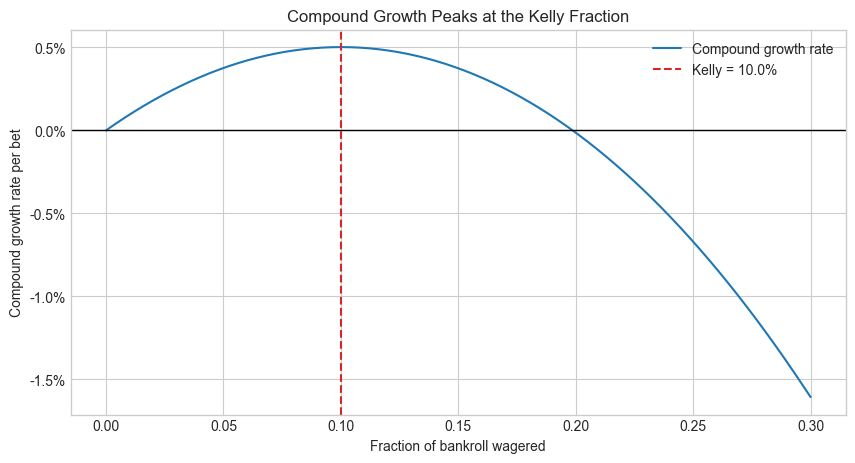

In [73]:
fractions = np.linspace(0, 0.30, 300)
log_growth = expected_log_growth(fractions, p, b)
compound_growth = np.exp(log_growth) - 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fractions, compound_growth, label="Compound growth rate")
ax.axvline(f_star, color="tab:red", linestyle="--", label=f"Kelly = {f_star:.1%}")
ax.axhline(0, color="black", linewidth=1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax.set_title("Compound Growth Peaks at the Kelly Fraction")
ax.set_xlabel("Fraction of bankroll wagered")
ax.set_ylabel("Compound growth rate per bet")
ax.legend()
plt.show()

## Monte Carlo Check

Now simulate many possible futures and ask: after 200 bets, which bet size gives the best typical final bankroll?

In [74]:
def simulate_many_bankroll_paths(f, p, b, rounds, simulations, starting_bankroll=1.0, seed=None):
    rng = np.random.default_rng(seed)
    wins = rng.random((simulations, rounds)) < p
    multipliers = np.where(wins, 1 + b * f, 1 - f)
    cumulative = np.cumprod(multipliers, axis=1)
    starting_column = np.full((simulations, 1), starting_bankroll)
    return np.column_stack([starting_column, starting_bankroll * cumulative])

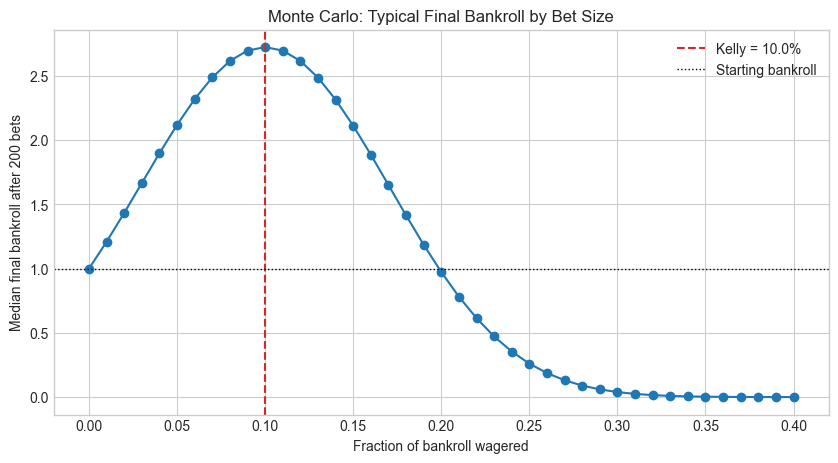

In [75]:
rounds = 200
simulations = 2_000
fractions_to_test = np.linspace(0, 0.40, 41)

median_final_bankrolls = []

for f in fractions_to_test:
    paths = simulate_many_bankroll_paths(f, p, b, rounds, simulations, seed=42)
    median_final_bankrolls.append(np.median(paths[:, -1]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(fractions_to_test, median_final_bankrolls, marker="o")
ax.axvline(f_star, color="tab:red", linestyle="--", label=f"Kelly = {f_star:.1%}")
ax.axhline(1.0, color="black", linewidth=1, linestyle=":", label="Starting bankroll")
ax.set_title("Monte Carlo: Typical Final Bankroll by Bet Size")
ax.set_xlabel("Fraction of bankroll wagered")
ax.set_ylabel("Median final bankroll after 200 bets")
ax.legend()
plt.show()

The theory and simulation are pointing at the same idea: the game has an edge, but oversized bets damage typical compounded results.

In [76]:
strategies = {
    "5%: under Kelly": 0.05,
    "10%: Kelly": 0.10,
    "20%: over Kelly": 0.20,
}

print(f"{'Strategy':<18} | {'10th pct':>10} | {'Median':>10} | {'90th pct':>10}")
print('-' * 59)

for label, f in strategies.items():
    paths = simulate_many_bankroll_paths(f, p, b, rounds, simulations, seed=42)
    p10, p50, p90 = np.percentile(paths[:, -1], [10, 50, 90])
    print(f"{label:<18} | {p10:>10.2f} | {p50:>10.2f} | {p90:>10.2f}")

Strategy           |   10th pct |     Median |   90th pct
-----------------------------------------------------------
5%: under Kelly    |       0.86 |       2.12 |       5.21
10%: Kelly         |       0.45 |       2.72 |      16.57
20%: over Kelly    |       0.03 |       0.97 |      37.40
